In [1]:
## =============================================================================
## FASE A.1 - SETUP: imports, paths y configuración
## =============================================================================

import os
import json
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

## --- Rutas (ajustar el TIMESTAMP al de TU corrida) ---
ROOT_DIR = Path(r"C:\Users\diego.perezp\Documents\GitHub\Predictive model of university admission")
OUTPUTS_MODELADO = ROOT_DIR / "OUTPUTS_MODELADO"
OUTPUTS_PAPER = ROOT_DIR / "OUTPUTS_PAPER"
FIGURAS_DIR = OUTPUTS_PAPER / "figuras"
TABLAS_DIR = OUTPUTS_PAPER / "tablas"
for d in [OUTPUTS_PAPER, FIGURAS_DIR, TABLAS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

## Detectar automáticamente el parquet más reciente
parquets_disponibles = sorted(OUTPUTS_MODELADO.glob("predicciones_modelo_final_*.parquet"))
assert len(parquets_disponibles) > 0, f"No hay parquets en {OUTPUTS_MODELADO}"
PARQUET_PATH = parquets_disponibles[-1]
print(f"Parquet detectado (más reciente): {PARQUET_PATH.name}")

## --- Configuración de matplotlib para calidad de paper ---
mpl.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 300,           ## resolución alta para PNG exportado
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.15,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_palette("Set2")

PALETA_COLORES = {
    "real": "#2C3E50",
    "pred": "#E67E22",
    "error": "#C0392B",
    "ok": "#27AE60",
    "warning": "#F39C12",
    "neutral": "#7F8C8D",
}

print(f"\nFiguras se guardarán en: {FIGURAS_DIR}")
print(f"Tablas se guardarán en:  {TABLAS_DIR}")

Parquet detectado (más reciente): predicciones_modelo_final_20260615_1210.parquet

Figuras se guardarán en: C:\Users\diego.perezp\Documents\GitHub\Predictive model of university admission\OUTPUTS_PAPER\figuras
Tablas se guardarán en:  C:\Users\diego.perezp\Documents\GitHub\Predictive model of university admission\OUTPUTS_PAPER\tablas


In [2]:
## =============================================================================
## FASE A.2 - CARGA Y VALIDACIÓN DEL PARQUET
## =============================================================================

df_full = pd.read_parquet(PARQUET_PATH)
print(f"Shape cargado: {df_full.shape}")
print(f"Memoria: {df_full.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

print(f"\nDistribución por tipo_registro:")
print(df_full["tipo_registro"].value_counts().to_string())

print(f"\nAños cubiertos: {sorted(df_full['anio'].unique())}")

## --- Subsets de trabajo ---
##   df_oof:     filas retrospectivas con predicción válida (2019-2025)
##   df_holdout: solo 2025 (subset de df_oof, para reporte de holdout final)
##   df_2018:    histórico sin predicción (línea base para el gráfico temporal)
##   df_forecast: 2026 (sin matrícula real)
df_oof = df_full[df_full["tipo_registro"] == "retrospectivo"].copy()
df_holdout = df_oof[df_oof["anio"] == 2025].copy()
df_2018 = df_full[df_full["tipo_registro"] == "historico_sin_pred"].copy()
df_forecast = df_full[df_full["tipo_registro"] == "forecast"].copy()

print(f"\nSubsets construidos:")
print(f"  df_oof (OOF retrospectivo 2019-2025): {len(df_oof):,} filas")
print(f"  df_holdout (solo 2025):                {len(df_holdout):,} filas")
print(f"  df_2018 (histórico base de lag):       {len(df_2018):,} filas")
print(f"  df_forecast (2026):                    {len(df_forecast):,} filas")

## Validaciones
assert df_oof["matriculas_real"].notna().all(), "Hay matriculas_real NaN en OOF"
assert df_oof["matriculas_pred"].notna().all(), "Hay matriculas_pred NaN en OOF"
print("\nValidaciones OK")

Shape cargado: (70917, 31)
Memoria: 26.1 MB

Distribución por tipo_registro:
tipo_registro
retrospectivo         54721
historico_sin_pred     8444
forecast               7752

Años cubiertos: [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]

Subsets construidos:
  df_oof (OOF retrospectivo 2019-2025): 54,721 filas
  df_holdout (solo 2025):                7,752 filas
  df_2018 (histórico base de lag):       8,444 filas
  df_forecast (2026):                    7,752 filas

Validaciones OK


In [3]:
## =============================================================================
## FASE A.3 - HELPERS: funciones de métricas reutilizables
## =============================================================================

def calcular_metricas(real, pred, label=""):
    ## Métricas estándar sobre cualquier par (real, pred)
    real = np.asarray(real, dtype=float)
    pred = np.asarray(pred, dtype=float)
    n = len(real)

    rmse = float(np.sqrt(np.mean((real - pred) ** 2)))
    mae = float(np.mean(np.abs(real - pred)))
    medae = float(np.median(np.abs(real - pred)))

    ## R²
    ss_res = np.sum((real - pred) ** 2)
    ss_tot = np.sum((real - real.mean()) ** 2)
    r2 = float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan

    ## WAPE (Weighted Absolute Percentage Error)
    total_real = real.sum()
    wape = float(np.sum(np.abs(real - pred)) / total_real * 100) if total_real > 0 else np.nan

    ## MAPE (excluyendo reales == 0)
    mask_nz = real > 0
    if mask_nz.sum() > 0:
        mape = float(np.mean(np.abs((real[mask_nz] - pred[mask_nz]) / real[mask_nz])) * 100)
    else:
        mape = np.nan

    ## sMAPE (más robusto que MAPE)
    smape = float(np.mean(2 * np.abs(real - pred) / (np.abs(real) + np.abs(pred) + 1e-10)) * 100)

    ## Error agregado (suma)
    error_agg_abs = float(abs(real.sum() - pred.sum()))
    error_agg_rel = float(error_agg_abs / total_real * 100) if total_real > 0 else np.nan

    return {
        "n": int(n),
        "RMSE": rmse,
        "MAE": mae,
        "MedAE": medae,
        "R²": r2,
        "WAPE_%": wape,
        "confianza_%": 100 - wape,
        "MAPE_%": mape,
        "sMAPE_%": smape,
        "error_agregado_abs": error_agg_abs,
        "error_agregado_rel_%": error_agg_rel,
        "total_real": float(total_real),
        "total_pred": float(pred.sum()),
    }


def metricas_agregadas_por_nivel(df, group_cols, label):
    ## Agrega matriculas (suma) por las group_cols y calcula métricas sobre
    ## los pares (real_agregado, pred_agregado).
    agg = df.groupby(group_cols, observed=True, as_index=False).agg(
        real=("matriculas_real", "sum"),
        pred=("matriculas_pred", "sum"),
    )
    ## Eliminar grupos con real = 0 (no aportan a métricas relativas)
    agg = agg[agg["real"] > 0].copy()
    m = calcular_metricas(agg["real"].values, agg["pred"].values, label=label)
    m["nivel"] = label
    m["n_grupos"] = len(agg)
    m["columnas_agrupacion"] = " × ".join(group_cols)
    return m, agg


def guardar_figura(fig, filename, dpi=300):
    path = FIGURAS_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight", pad_inches=0.15)
    print(f"  Figura guardada: {filename}")
    return path


def df_a_markdown(df, filename, float_fmt="{:.4f}"):
    ## Exporta un dataframe a archivo .md con formato de tabla
    md = df.to_markdown(index=False, floatfmt=".4f")
    path = TABLAS_DIR / filename
    with open(path, "w", encoding="utf-8") as f:
        f.write(md)
    print(f"  Tabla guardada: {filename}")
    return md

print("Helpers de métricas cargados correctamente.")

Helpers de métricas cargados correctamente.


In [4]:
## =============================================================================
## FASE B.1 - MÉTRICAS GLOBALES (OOF retrospectivo vs Holdout 2025)
## =============================================================================

m_oof = calcular_metricas(df_oof["matriculas_real"].values,
                          df_oof["matriculas_pred"].values, "OOF")
m_holdout = calcular_metricas(df_holdout["matriculas_real"].values,
                              df_holdout["matriculas_pred"].values, "Holdout 2025")

## --- Tabla comparativa ---
tabla_global = pd.DataFrame({
    "OOF retrospectivo (2019-2025)": m_oof,
    "Holdout 2025": m_holdout,
}).T

cols_orden = ["n", "RMSE", "MAE", "MedAE", "R²", "WAPE_%", "confianza_%",
              "MAPE_%", "sMAPE_%", "error_agregado_abs", "error_agregado_rel_%"]
tabla_global = tabla_global[cols_orden]

print("=" * 80)
print("MÉTRICAS A NIVEL FILA INDIVIDUAL (granularidad máxima)")
print("=" * 80)
print(tabla_global.to_string())

## --- Skill score vs predicción naïve (matriculas_lag) ---
## Baseline naïve: predecir que la matrícula del año t es igual a la del año t-1
naive_pred_oof = df_oof["matriculas_lag"].values
naive_pred_holdout = df_holdout["matriculas_lag"].values

m_naive_oof = calcular_metricas(df_oof["matriculas_real"].values, naive_pred_oof, "Naïve")
m_naive_holdout = calcular_metricas(df_holdout["matriculas_real"].values, naive_pred_holdout, "Naïve")

skill_oof = 1 - (m_oof["RMSE"]**2) / (m_naive_oof["RMSE"]**2)
skill_holdout = 1 - (m_holdout["RMSE"]**2) / (m_naive_holdout["RMSE"]**2)

print(f"\n{'='*80}")
print("COMPARACIÓN CONTRA BASELINE NAÏVE (matrícula_t = matrícula_t-1)")
print("=" * 80)
print(f"  OOF retrospectivo:")
print(f"    Modelo - RMSE: {m_oof['RMSE']:.2f}   WAPE: {m_oof['WAPE_%']:.2f}%")
print(f"    Naïve  - RMSE: {m_naive_oof['RMSE']:.2f}   WAPE: {m_naive_oof['WAPE_%']:.2f}%")
print(f"    Skill Score (mejora % sobre naïve): {skill_oof*100:+.2f}%")
print(f"\n  Holdout 2025:")
print(f"    Modelo - RMSE: {m_holdout['RMSE']:.2f}   WAPE: {m_holdout['WAPE_%']:.2f}%")
print(f"    Naïve  - RMSE: {m_naive_holdout['RMSE']:.2f}   WAPE: {m_naive_holdout['WAPE_%']:.2f}%")
print(f"    Skill Score (mejora % sobre naïve): {skill_holdout*100:+.2f}%")

MÉTRICAS A NIVEL FILA INDIVIDUAL (granularidad máxima)
                                     n       RMSE        MAE     MedAE        R²     WAPE_%  confianza_%     MAPE_%    sMAPE_%  error_agregado_abs  error_agregado_rel_%
OOF retrospectivo (2019-2025)  54721.0  36.637800  13.395717  6.652319  0.876737  18.357024    81.642976  87.129551  26.655478       129200.094258              3.235528
Holdout 2025                    7752.0  26.593088  11.562845  6.188025  0.943952  15.012809    84.987191  68.966613  23.138223         3814.092671              0.638814

COMPARACIÓN CONTRA BASELINE NAÏVE (matrícula_t = matrícula_t-1)
  OOF retrospectivo:
    Modelo - RMSE: 36.64   WAPE: 18.36%
    Naïve  - RMSE: 59.54   WAPE: 22.00%
    Skill Score (mejora % sobre naïve): +62.13%

  Holdout 2025:
    Modelo - RMSE: 26.59   WAPE: 15.01%
    Naïve  - RMSE: 37.40   WAPE: 17.23%
    Skill Score (mejora % sobre naïve): +49.45%


Estadísticos de residuos (real - pred, en N° de matrículas):
  mean:    -2.361  (sesgo notable)
  median:  -0.709
  std:     36.562
  min:     -2248
  max:     421
  skew:    -17.291
  kurt:    +729.052  (exceso sobre normal=0)

  Test Shapiro-Wilk (normalidad sobre muestra de 5000):
    statistic: 0.5348, p-value: 1.34e-78
    -> rechazamos normalidad
  Figura guardada: fig01_distribucion_residuos.png


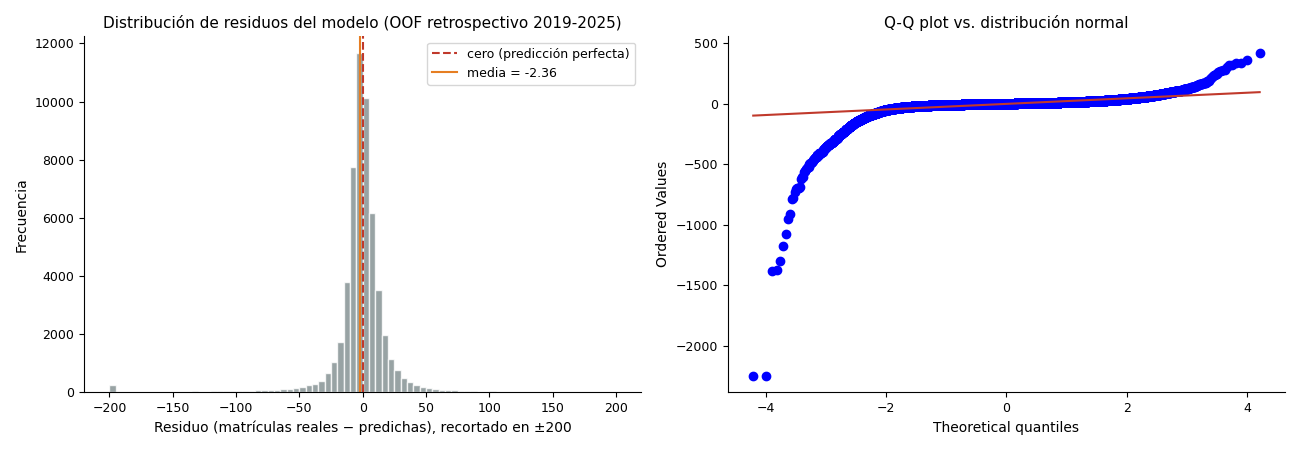

In [5]:
## =============================================================================
## FASE B.2 - DISTRIBUCIÓN DE RESIDUOS
## =============================================================================

residuos_oof = (df_oof["matriculas_real"] - df_oof["matriculas_pred"]).values

print(f"Estadísticos de residuos (real - pred, en N° de matrículas):")
print(f"  mean:    {residuos_oof.mean():+.3f}  ({'sesgo casi cero' if abs(residuos_oof.mean()) < 1 else 'sesgo notable'})")
print(f"  median:  {np.median(residuos_oof):+.3f}")
print(f"  std:     {residuos_oof.std():.3f}")
print(f"  min:     {residuos_oof.min():.0f}")
print(f"  max:     {residuos_oof.max():.0f}")
print(f"  skew:    {stats.skew(residuos_oof):+.3f}")
print(f"  kurt:    {stats.kurtosis(residuos_oof):+.3f}  (exceso sobre normal=0)")

## Test Shapiro (sobre muestra, porque scipy limita a 5000)
sample = np.random.RandomState(42).choice(residuos_oof, min(5000, len(residuos_oof)), replace=False)
shapiro_stat, shapiro_p = stats.shapiro(sample)
print(f"\n  Test Shapiro-Wilk (normalidad sobre muestra de {len(sample)}):")
print(f"    statistic: {shapiro_stat:.4f}, p-value: {shapiro_p:.2e}")
print(f"    {'-> rechazamos normalidad' if shapiro_p < 0.05 else '-> no se rechaza normalidad'}")

## --- Figura: histograma + Q-Q plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(np.clip(residuos_oof, -200, 200), bins=80,
             color=PALETA_COLORES["neutral"], edgecolor="white", alpha=0.8)
axes[0].axvline(0, color=PALETA_COLORES["error"], linestyle="--", linewidth=1.5, label="cero (predicción perfecta)")
axes[0].axvline(residuos_oof.mean(), color=PALETA_COLORES["pred"], linestyle="-", linewidth=1.5,
                label=f"media = {residuos_oof.mean():+.2f}")
axes[0].set_xlabel("Residuo (matrículas reales − predichas), recortado en ±200")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de residuos del modelo (OOF retrospectivo 2019-2025)")
axes[0].legend()

stats.probplot(residuos_oof, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot vs. distribución normal")
axes[1].get_lines()[1].set_color(PALETA_COLORES["error"])

plt.tight_layout()
guardar_figura(fig, "fig01_distribucion_residuos.png")
plt.show()

  Figura guardada: fig02_scatter_pred_vs_real.png


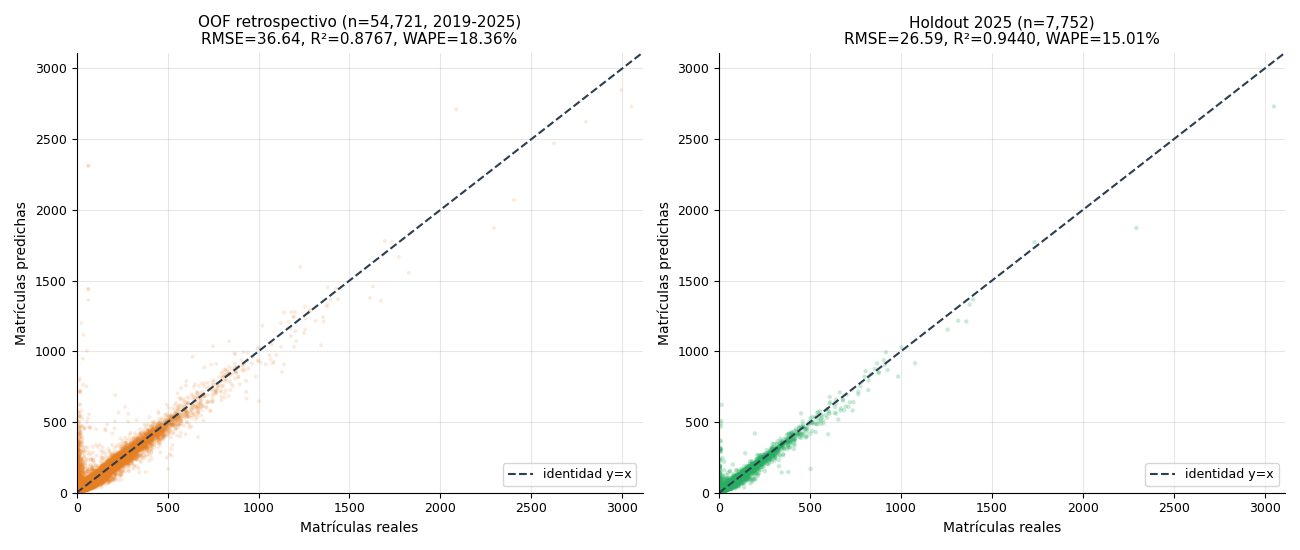

In [6]:
## =============================================================================
## FASE B.3 - SCATTER PREDICHO vs REAL (figura principal del modelo)
## =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

## --- Panel 1: OOF retrospectivo ---
ax = axes[0]
real = df_oof["matriculas_real"].values
pred = df_oof["matriculas_pred"].values
ax.scatter(real, pred, alpha=0.15, s=8, color=PALETA_COLORES["pred"], edgecolor="none")
lims = [0, max(real.max(), pred.max()) * 1.02]
ax.plot(lims, lims, color=PALETA_COLORES["real"], linestyle="--", linewidth=1.5, label="identidad y=x")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Matrículas reales")
ax.set_ylabel("Matrículas predichas")
ax.set_title(f"OOF retrospectivo (n={len(df_oof):,}, 2019-2025)\nRMSE={m_oof['RMSE']:.2f}, R²={m_oof['R²']:.4f}, WAPE={m_oof['WAPE_%']:.2f}%")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

## --- Panel 2: Holdout 2025 ---
ax = axes[1]
real = df_holdout["matriculas_real"].values
pred = df_holdout["matriculas_pred"].values
ax.scatter(real, pred, alpha=0.25, s=10, color=PALETA_COLORES["ok"], edgecolor="none")
lims = [0, max(real.max(), pred.max()) * 1.02]
ax.plot(lims, lims, color=PALETA_COLORES["real"], linestyle="--", linewidth=1.5, label="identidad y=x")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Matrículas reales")
ax.set_ylabel("Matrículas predichas")
ax.set_title(f"Holdout 2025 (n={len(df_holdout):,})\nRMSE={m_holdout['RMSE']:.2f}, R²={m_holdout['R²']:.4f}, WAPE={m_holdout['WAPE_%']:.2f}%")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
guardar_figura(fig, "fig02_scatter_pred_vs_real.png")
plt.show()

Métricas año a año (sobre OOF):
 año    n      RMSE       MAE       R²    WAPE_%  confianza_%  error_agregado_rel_%
2019 8264 28.190598 12.218164 0.920534 17.604613    82.395387              3.467070
2020 7967 55.118777 14.135777 0.673666 20.444831    79.555169              6.795307
2021 7652 38.199277 15.408983 0.866370 20.994764    79.005236              1.019170
2022 7595 31.033133 14.006893 0.911728 19.081797    80.918203              7.219228
2023 7607 42.344027 14.556659 0.841278 19.488160    80.511840              4.372252
2024 7884 25.383840 12.021410 0.942627 16.218045    83.781955              0.835453
2025 7752 26.593088 11.562845 0.943952 15.012809    84.987191              0.638814
  Figura guardada: fig03_metricas_por_anio.png


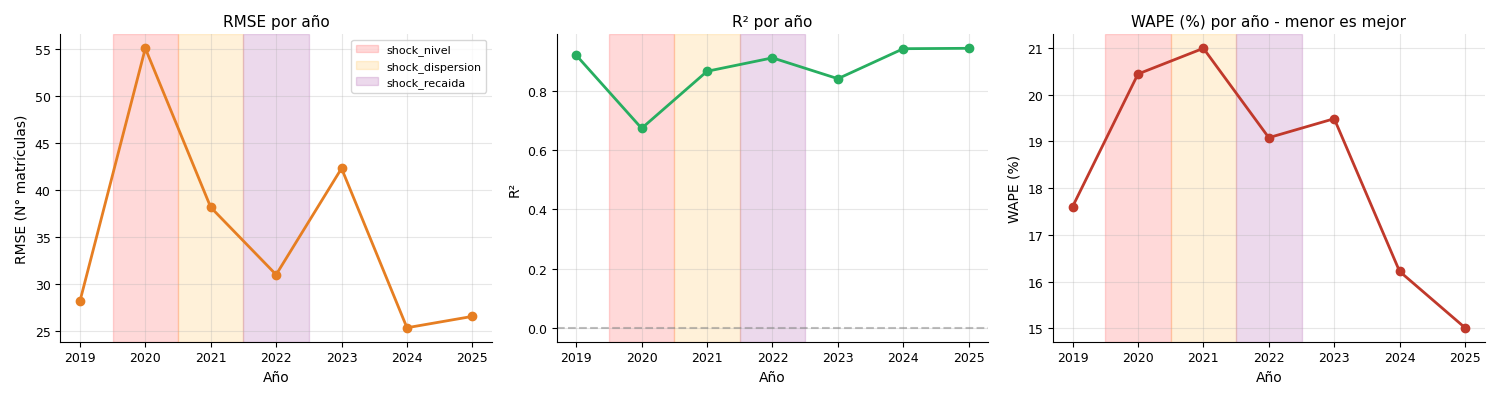

  Tabla guardada: tabla_metricas_por_anio.md


'|       año |         n |    RMSE |     MAE |     R² |   WAPE_% |   confianza_% |   error_agregado_rel_% |\n|----------:|----------:|--------:|--------:|-------:|---------:|--------------:|-----------------------:|\n| 2019.0000 | 8264.0000 | 28.1906 | 12.2182 | 0.9205 |  17.6046 |       82.3954 |                 3.4671 |\n| 2020.0000 | 7967.0000 | 55.1188 | 14.1358 | 0.6737 |  20.4448 |       79.5552 |                 6.7953 |\n| 2021.0000 | 7652.0000 | 38.1993 | 15.4090 | 0.8664 |  20.9948 |       79.0052 |                 1.0192 |\n| 2022.0000 | 7595.0000 | 31.0331 | 14.0069 | 0.9117 |  19.0818 |       80.9182 |                 7.2192 |\n| 2023.0000 | 7607.0000 | 42.3440 | 14.5567 | 0.8413 |  19.4882 |       80.5118 |                 4.3723 |\n| 2024.0000 | 7884.0000 | 25.3838 | 12.0214 | 0.9426 |  16.2180 |       83.7820 |                 0.8355 |\n| 2025.0000 | 7752.0000 | 26.5931 | 11.5628 | 0.9440 |  15.0128 |       84.9872 |                 0.6388 |'

In [7]:
## =============================================================================
## FASE B.4 - MÉTRICAS POR AÑO (evolución temporal del desempeño)
## =============================================================================

filas = []
for anio in sorted(df_oof["anio"].unique()):
    sub = df_oof[df_oof["anio"] == anio]
    m = calcular_metricas(sub["matriculas_real"].values, sub["matriculas_pred"].values, label=str(anio))
    m["año"] = int(anio)
    filas.append(m)

tabla_anios = pd.DataFrame(filas)[["año", "n", "RMSE", "MAE", "R²", "WAPE_%", "confianza_%", "error_agregado_rel_%"]]
print("Métricas año a año (sobre OOF):")
print(tabla_anios.to_string(index=False))

## --- Figura: evolución de RMSE, R² y WAPE por año ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(tabla_anios["año"], tabla_anios["RMSE"], marker="o", color=PALETA_COLORES["pred"], linewidth=2)
axes[0].axvspan(2019.5, 2020.5, alpha=0.15, color="red", label="shock_nivel")
axes[0].axvspan(2020.5, 2021.5, alpha=0.15, color="orange", label="shock_dispersion")
axes[0].axvspan(2021.5, 2022.5, alpha=0.15, color="purple", label="shock_recaida")
axes[0].set_title("RMSE por año")
axes[0].set_xlabel("Año"); axes[0].set_ylabel("RMSE (N° matrículas)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(tabla_anios["año"], tabla_anios["R²"], marker="o", color=PALETA_COLORES["ok"], linewidth=2)
axes[1].axvspan(2019.5, 2020.5, alpha=0.15, color="red")
axes[1].axvspan(2020.5, 2021.5, alpha=0.15, color="orange")
axes[1].axvspan(2021.5, 2022.5, alpha=0.15, color="purple")
axes[1].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[1].set_title("R² por año")
axes[1].set_xlabel("Año"); axes[1].set_ylabel("R²")
axes[1].grid(True, alpha=0.3)

axes[2].plot(tabla_anios["año"], tabla_anios["WAPE_%"], marker="o", color=PALETA_COLORES["error"], linewidth=2)
axes[2].axvspan(2019.5, 2020.5, alpha=0.15, color="red")
axes[2].axvspan(2020.5, 2021.5, alpha=0.15, color="orange")
axes[2].axvspan(2021.5, 2022.5, alpha=0.15, color="purple")
axes[2].set_title("WAPE (%) por año - menor es mejor")
axes[2].set_xlabel("Año"); axes[2].set_ylabel("WAPE (%)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
guardar_figura(fig, "fig03_metricas_por_anio.png")
plt.show()

## Guardar tabla MD
df_a_markdown(tabla_anios, "tabla_metricas_por_anio.md")

Métricas por región (ordenadas por menor WAPE = mejor):
                 region     n      RMSE       MAE       R²    WAPE_%  confianza_%  error_agregado_rel_%
               Los Ríos  1637 15.537461  9.009952 0.947858 12.989134    87.010866              1.347114
                  Maule  2557 27.640064 12.658622 0.891470 15.930357    84.069643              4.223250
           La Araucanía  3771 21.104542 10.010550 0.894368 16.416661    83.583339              3.907493
            Antofagasta  2213 14.533009  8.528103 0.934434 16.700611    83.299389              1.556969
                 Biobío  6087 30.507392 13.406655 0.884275 17.011663    82.988337              2.954103
               Coquimbo  2245 18.354101 10.016042 0.902882 17.468121    82.531879              0.035610
                  Ñuble  1557 15.750764  8.695600 0.915538 18.155186    81.844814              2.285287
             Magallanes   669 10.785483  6.756335 0.915635 18.546585    81.453415              1.898657
     Ari

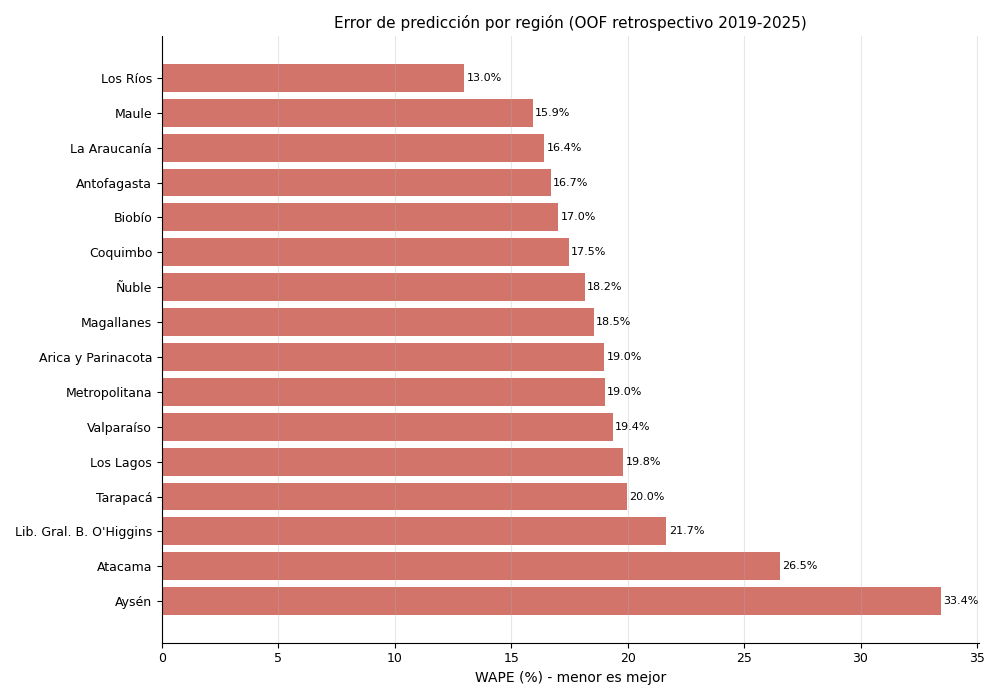

  Tabla guardada: tabla_metricas_por_region.md


"| region                  |     n |    RMSE |     MAE |     R² |   WAPE_% |   confianza_% |   error_agregado_rel_% |\n|:------------------------|------:|--------:|--------:|-------:|---------:|--------------:|-----------------------:|\n| Los Ríos                |  1637 | 15.5375 |  9.0100 | 0.9479 |  12.9891 |       87.0109 |                 1.3471 |\n| Maule                   |  2557 | 27.6401 | 12.6586 | 0.8915 |  15.9304 |       84.0696 |                 4.2232 |\n| La Araucanía            |  3771 | 21.1045 | 10.0106 | 0.8944 |  16.4167 |       83.5833 |                 3.9075 |\n| Antofagasta             |  2213 | 14.5330 |  8.5281 | 0.9344 |  16.7006 |       83.2994 |                 1.5570 |\n| Biobío                  |  6087 | 30.5074 | 13.4067 | 0.8843 |  17.0117 |       82.9883 |                 2.9541 |\n| Coquimbo                |  2245 | 18.3541 | 10.0160 | 0.9029 |  17.4681 |       82.5319 |                 0.0356 |\n| Ñuble                   |  1557 | 15.7508 |  8.6956 |

In [8]:
## =============================================================================
## FASE B.5 - MÉTRICAS POR REGIÓN
## =============================================================================

filas = []
for region in df_oof["region"].unique():
    sub = df_oof[df_oof["region"] == region]
    if len(sub) < 30:
        continue
    m = calcular_metricas(sub["matriculas_real"].values, sub["matriculas_pred"].values, label=str(region))
    m["region"] = str(region)
    filas.append(m)

tabla_regiones = (pd.DataFrame(filas)[
    ["region", "n", "RMSE", "MAE", "R²", "WAPE_%", "confianza_%", "error_agregado_rel_%"]
].sort_values("WAPE_%"))
print("Métricas por región (ordenadas por menor WAPE = mejor):")
print(tabla_regiones.to_string(index=False))

## --- Figura: WAPE por región (barplot horizontal) ---
fig, ax = plt.subplots(figsize=(10, 7))
y = np.arange(len(tabla_regiones))
ax.barh(y, tabla_regiones["WAPE_%"].values, color=PALETA_COLORES["error"], alpha=0.7)
ax.set_yticks(y)
ax.set_yticklabels(tabla_regiones["region"].values)
ax.set_xlabel("WAPE (%) - menor es mejor")
ax.set_title("Error de predicción por región (OOF retrospectivo 2019-2025)")
for i, v in enumerate(tabla_regiones["WAPE_%"].values):
    ax.text(v + 0.1, i, f"{v:.1f}%", va="center", fontsize=8)
ax.grid(True, axis="x", alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
guardar_figura(fig, "fig04_wape_por_region.png")
plt.show()

df_a_markdown(tabla_regiones, "tabla_metricas_por_region.md")

In [9]:
## =============================================================================
## FASE C.1 - ANÁLISIS MACRO → MICRO: métricas en 8 niveles de agregación
## =============================================================================
## Este es el análisis más importante del paper: muestra cómo la precisión del
## modelo cambia con la granularidad. A mayor agregación, los errores
## idiosincráticos se cancelan y el WAPE baja.

NIVELES_AGREGACION = [
    ("Nivel 1: Nacional anual", ["anio"]),
    ("Nivel 2: + Institución", ["anio", "institucion"]),
    ("Nivel 3: + Área conocimiento", ["anio", "institucion", "area_conocimiento"]),
    ("Nivel 4: + Región", ["anio", "institucion", "area_conocimiento", "region"]),
    ("Nivel 5: + Carrera", ["anio", "institucion", "area_conocimiento", "region", "carrera"]),
    ("Nivel 6: + Condición", ["anio", "institucion", "area_conocimiento", "region", "carrera", "condicion"]),
    ("Nivel 7: + Género", ["anio", "institucion", "area_conocimiento", "region", "carrera", "condicion", "genero"]),
    ("Nivel 8: + Jornada (granularidad fina)",
     ["anio", "institucion", "area_conocimiento", "region", "carrera", "condicion", "genero", "jornada"]),
]

resultados_oof = []
resultados_holdout = []
aggs_por_nivel = {}

for label, cols in NIVELES_AGREGACION:
    m_oof_n, agg_oof = metricas_agregadas_por_nivel(df_oof, cols, label + " [OOF]")
    m_hold_n, agg_hold = metricas_agregadas_por_nivel(df_holdout, cols, label + " [Holdout 2025]")
    resultados_oof.append(m_oof_n)
    resultados_holdout.append(m_hold_n)
    aggs_por_nivel[label] = {"oof": agg_oof, "holdout": agg_hold}

cols_mostrar = ["nivel", "n_grupos", "WAPE_%", "confianza_%", "R²", "RMSE", "MAE", "error_agregado_rel_%"]
tabla_oof = pd.DataFrame(resultados_oof)[cols_mostrar]
tabla_holdout = pd.DataFrame(resultados_holdout)[cols_mostrar]

print("=" * 100)
print("MÉTRICAS POR NIVEL DE AGREGACIÓN - OOF RETROSPECTIVO (2019-2025)")
print("=" * 100)
print(tabla_oof.to_string(index=False))

print(f"\n{'='*100}")
print("MÉTRICAS POR NIVEL DE AGREGACIÓN - HOLDOUT 2025")
print("=" * 100)
print(tabla_holdout.to_string(index=False))

df_a_markdown(tabla_oof, "tabla_macro_a_micro_OOF.md")
df_a_markdown(tabla_holdout, "tabla_macro_a_micro_HOLDOUT.md")

MÉTRICAS POR NIVEL DE AGREGACIÓN - OOF RETROSPECTIVO (2019-2025)
                                       nivel  n_grupos    WAPE_%  confianza_%        R²         RMSE          MAE  error_agregado_rel_%
               Nivel 1: Nacional anual [OOF]         7  3.426558    96.573442 -1.653629 24215.621180 19546.892857              3.235529
                Nivel 2: + Institución [OOF]       368  6.143768    93.856232  0.977851  1339.563516   666.660451              3.235528
          Nivel 3: + Área conocimiento [OOF]      2755  8.870258    91.129742  0.972658   398.586514   128.567837              3.235528
                     Nivel 4: + Región [OOF]      4324  9.521167    90.478833  0.970011   281.869488    87.926985              3.235528
                    Nivel 5: + Carrera [OOF]     15586 13.350792    86.649208  0.856787   109.898159    34.205035              3.235528
                  Nivel 6: + Condición [OOF]     29509 16.098482    83.901518  0.876244    66.260263    21.784527      

'| nivel                                                 |   n_grupos |   WAPE_% |   confianza_% |       R² |      RMSE |       MAE |   error_agregado_rel_% |\n|:------------------------------------------------------|-----------:|---------:|--------------:|---------:|----------:|----------:|-----------------------:|\n| Nivel 1: Nacional anual [Holdout 2025]                |          1 |   0.6388 |       99.3612 | nan      | 3814.0625 | 3814.0625 |                 0.6388 |\n| Nivel 2: + Institución [Holdout 2025]                 |         51 |   3.8834 |       96.1166 |   0.9928 |  825.6718 |  454.6345 |                 0.6388 |\n| Nivel 3: + Área conocimiento [Holdout 2025]           |        390 |   6.2667 |       93.7333 |   0.9866 |  298.7315 |   95.9377 |                 0.6388 |\n| Nivel 4: + Región [Holdout 2025]                      |        598 |   6.9206 |       93.0794 |   0.9880 |  193.5700 |   69.0975 |                 0.6388 |\n| Nivel 5: + Carrera [Holdout 2025]          

  Figura guardada: fig05_macro_a_micro.png


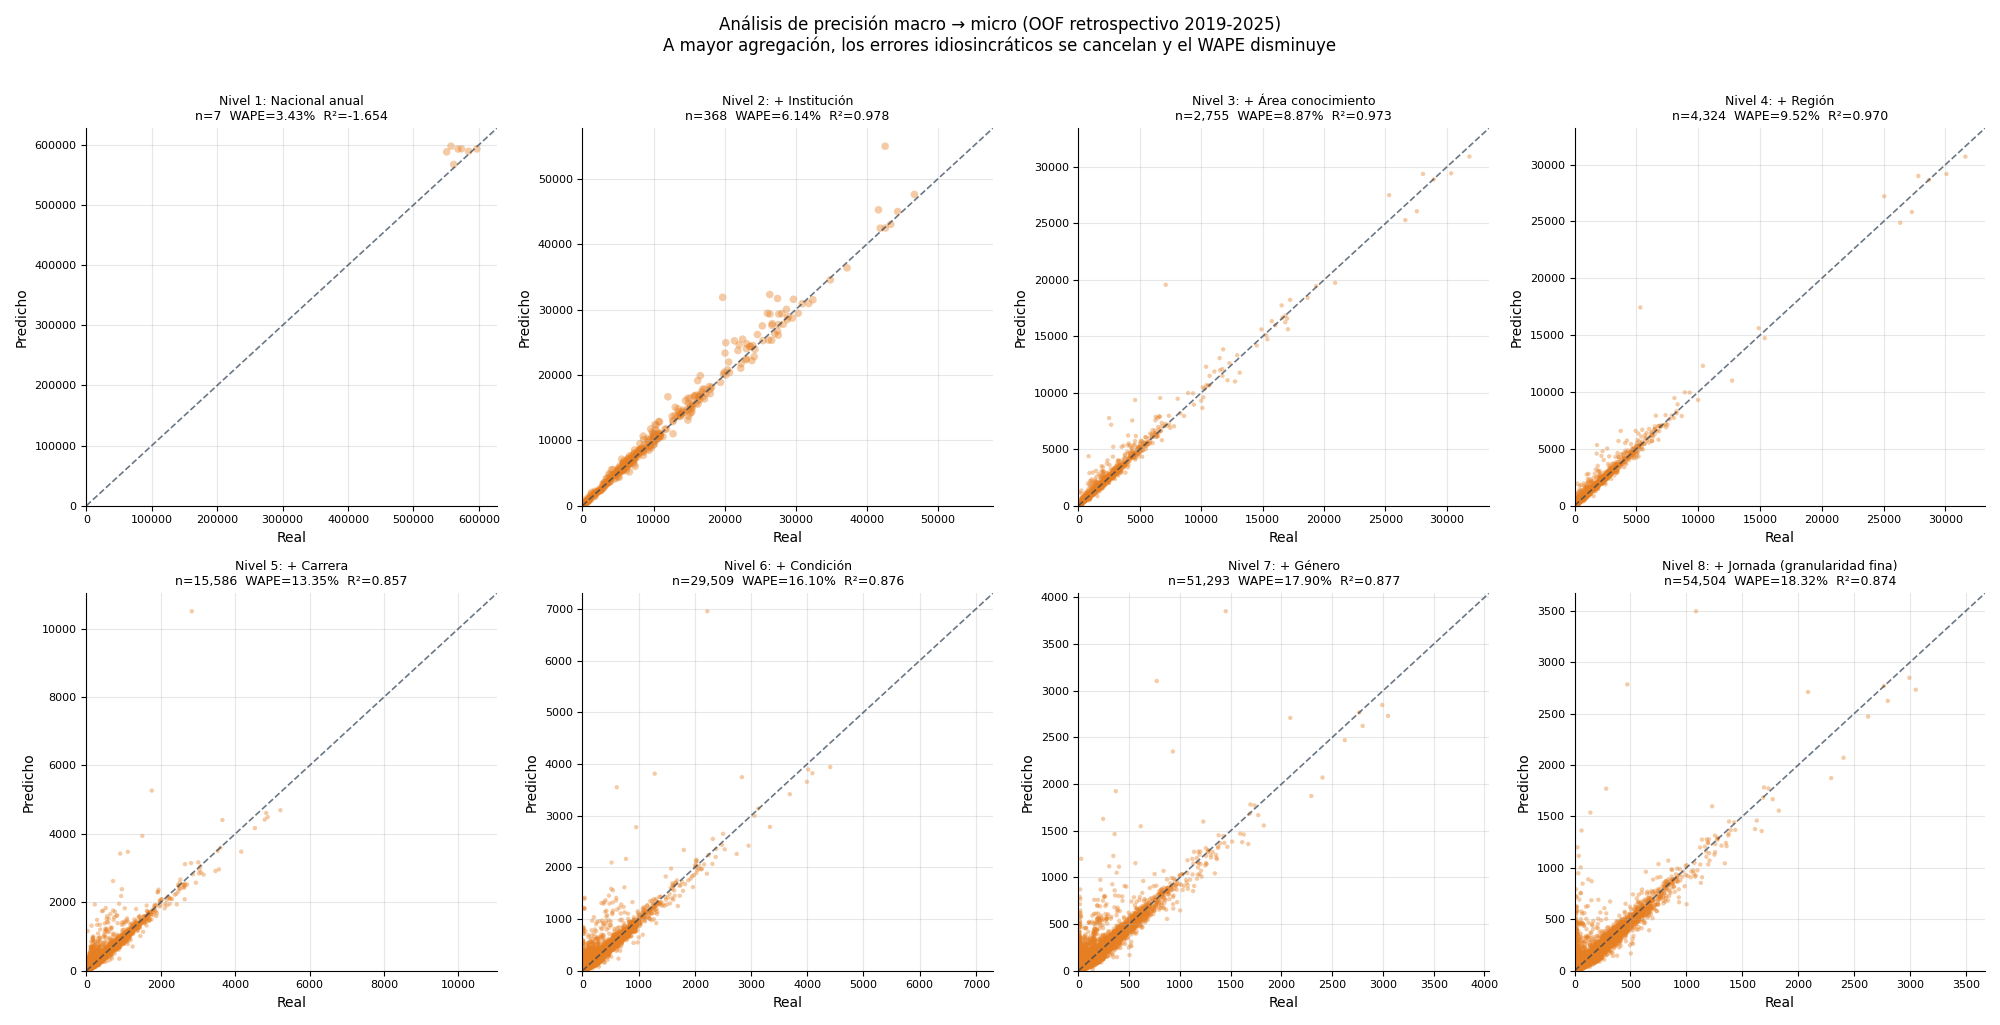

  Figura guardada: fig06_evolucion_metricas_por_nivel.png


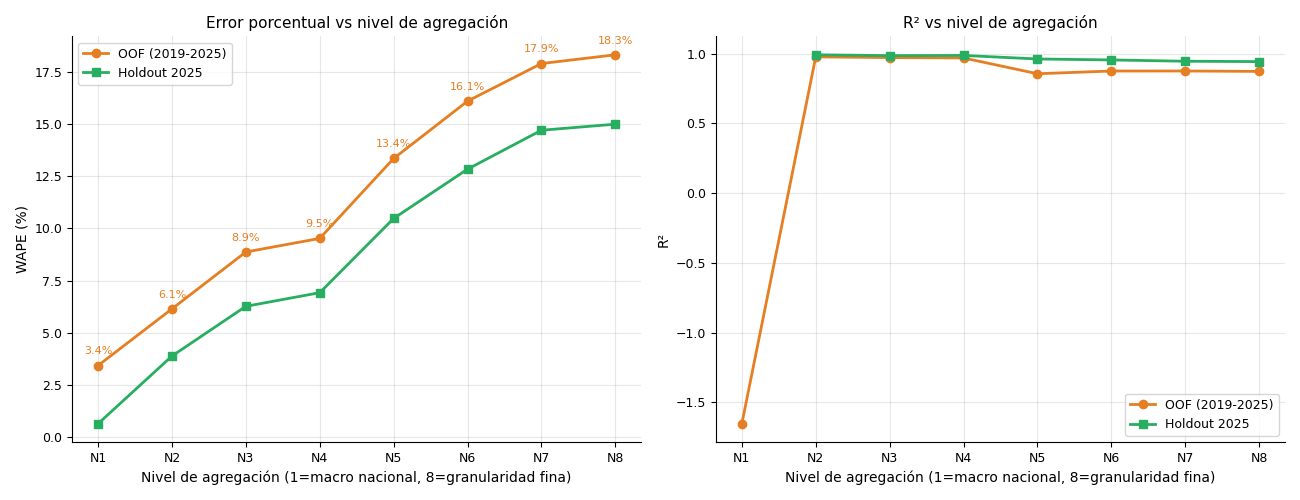

In [10]:
## =============================================================================
## FASE C.2 - VISUALIZACIÓN DE LOS 8 NIVELES (figura clave del paper)
## =============================================================================

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (label, cols) in enumerate(NIVELES_AGREGACION):
    ax = axes[idx]
    agg = aggs_por_nivel[label]["oof"]
    real = agg["real"].values
    pred = agg["pred"].values
    m = resultados_oof[idx]

    ax.scatter(real, pred, alpha=0.4, s=10 if len(agg) > 1000 else 30,
               color=PALETA_COLORES["pred"], edgecolor="none")
    lims = [0, max(real.max(), pred.max()) * 1.05]
    ax.plot(lims, lims, color=PALETA_COLORES["real"], linestyle="--", linewidth=1.2, alpha=0.7)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Real")
    ax.set_ylabel("Predicho")
    ax.set_title(f"{label}\nn={m['n_grupos']:,}  WAPE={m['WAPE_%']:.2f}%  R²={m['R²']:.3f}",
                 fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", labelsize=8)

plt.suptitle("Análisis de precisión macro → micro (OOF retrospectivo 2019-2025)\n"
             "A mayor agregación, los errores idiosincráticos se cancelan y el WAPE disminuye",
             fontsize=12, y=1.01)
plt.tight_layout()
guardar_figura(fig, "fig05_macro_a_micro.png")
plt.show()

## --- Gráfico de evolución: WAPE y R² por nivel ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

niveles_x = [f"N{i+1}" for i in range(len(NIVELES_AGREGACION))]
wape_oof_vals = [r["WAPE_%"] for r in resultados_oof]
wape_hold_vals = [r["WAPE_%"] for r in resultados_holdout]
r2_oof_vals = [r["R²"] for r in resultados_oof]
r2_hold_vals = [r["R²"] for r in resultados_holdout]

axes[0].plot(niveles_x, wape_oof_vals, marker="o", linewidth=2,
             label="OOF (2019-2025)", color=PALETA_COLORES["pred"])
axes[0].plot(niveles_x, wape_hold_vals, marker="s", linewidth=2,
             label="Holdout 2025", color=PALETA_COLORES["ok"])
axes[0].set_xlabel("Nivel de agregación (1=macro nacional, 8=granularidad fina)")
axes[0].set_ylabel("WAPE (%)")
axes[0].set_title("Error porcentual vs nivel de agregación")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for i, v in enumerate(wape_oof_vals):
    axes[0].annotate(f"{v:.1f}%", (i, v), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=8, color=PALETA_COLORES["pred"])

axes[1].plot(niveles_x, r2_oof_vals, marker="o", linewidth=2,
             label="OOF (2019-2025)", color=PALETA_COLORES["pred"])
axes[1].plot(niveles_x, r2_hold_vals, marker="s", linewidth=2,
             label="Holdout 2025", color=PALETA_COLORES["ok"])
axes[1].set_xlabel("Nivel de agregación (1=macro nacional, 8=granularidad fina)")
axes[1].set_ylabel("R²")
axes[1].set_title("R² vs nivel de agregación")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
guardar_figura(fig, "fig06_evolucion_metricas_por_nivel.png")
plt.show()

Calibración por decil de tamaño de matrícula:
             n  real_promedio  pred_promedio  sesgo_promedio  sesgo_relativo_%
bin_size                                                                      
Q1        5717           7.03      29.690001          -22.66           -322.33
Q2        5677          14.56      22.030001           -7.47             -51.3
Q3        5604          20.47      24.530001           -4.07            -19.88
Q4        5329          26.89      29.639999           -2.75            -10.23
Q5        5422          34.78      35.840000           -1.06             -3.05
Q6        5170          45.12      44.840000            0.27               0.6
Q7        5508          60.14      60.669998           -0.53             -0.88
Q8        5351          85.54      83.470001            2.07              2.42
Q9        5501         132.88     129.190002            3.69              2.78
Q10       5442         306.98     296.679993           10.30              3.36

Sesgo

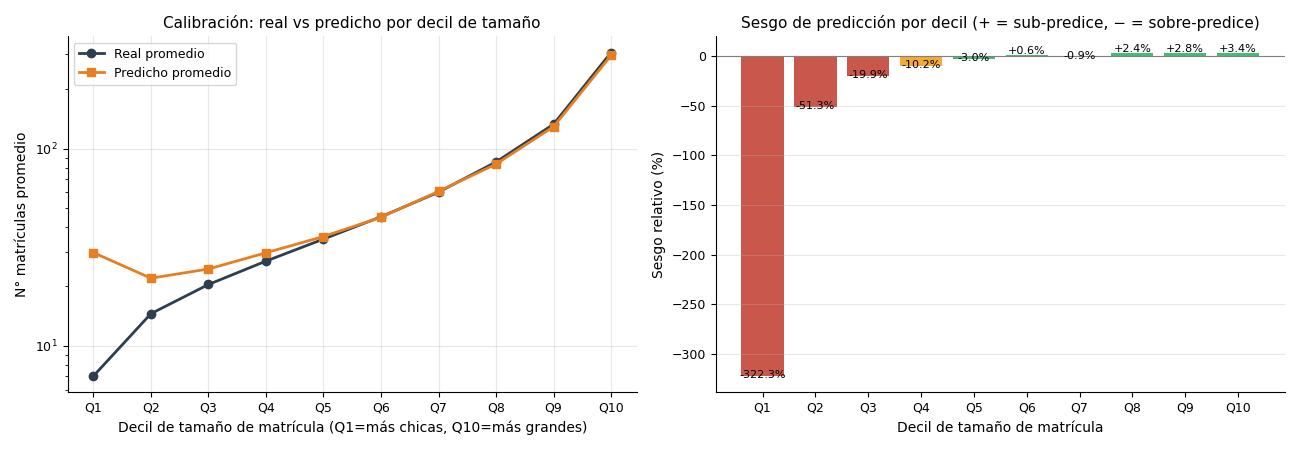

In [11]:
## =============================================================================
## FASE D.1 - ANÁLISIS DE CALIBRACIÓN (¿el modelo sub o sobre-predice?)
## =============================================================================
## Construimos bins por tamaño de matrícula real y vemos si en cada bin el
## modelo predice más, menos o igual.

df_calib = df_oof.copy()
df_calib["bin_size"] = pd.qcut(df_calib["matriculas_real"], q=10,
                                labels=[f"Q{i+1}" for i in range(10)],
                                duplicates="drop")

calib = df_calib.groupby("bin_size", observed=True).agg(
    n=("matriculas_real", "size"),
    real_promedio=("matriculas_real", "mean"),
    pred_promedio=("matriculas_pred", "mean"),
    sesgo_promedio=("residuo_matriculas", "mean"),
).round(2)
calib["sesgo_relativo_%"] = (calib["sesgo_promedio"] / calib["real_promedio"] * 100).round(2)

print("Calibración por decil de tamaño de matrícula:")
print(calib.to_string())
print("\nSesgo negativo => modelo sobre-predice. Positivo => modelo sub-predice.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(calib.index, calib["real_promedio"], marker="o", linewidth=2,
        label="Real promedio", color=PALETA_COLORES["real"])
ax.plot(calib.index, calib["pred_promedio"], marker="s", linewidth=2,
        label="Predicho promedio", color=PALETA_COLORES["pred"])
ax.set_xlabel("Decil de tamaño de matrícula (Q1=más chicas, Q10=más grandes)")
ax.set_ylabel("N° matrículas promedio")
ax.set_title("Calibración: real vs predicho por decil de tamaño")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale("log")

ax = axes[1]
colors = [PALETA_COLORES["ok"] if abs(s) < 5 else PALETA_COLORES["warning"] if abs(s) < 15
          else PALETA_COLORES["error"] for s in calib["sesgo_relativo_%"]]
ax.bar(calib.index.astype(str), calib["sesgo_relativo_%"], color=colors, alpha=0.85)
ax.axhline(0, color="gray", linestyle="-", linewidth=0.8)
ax.set_xlabel("Decil de tamaño de matrícula")
ax.set_ylabel("Sesgo relativo (%)")
ax.set_title("Sesgo de predicción por decil (+ = sub-predice, − = sobre-predice)")
for i, v in enumerate(calib["sesgo_relativo_%"]):
    ax.text(i, v + (1 if v >= 0 else -2), f"{v:+.1f}%", ha="center", fontsize=8)
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
guardar_figura(fig, "fig07_calibracion.png")
plt.show()

Histórico real:
anio
2018    612677
2019    573548
2020    550847
2021    561614
2022    557507
2023    568204
2024    584391
2025    597058

Predicciones OOF (retrospectivas):
anio
2019    593433.0
2020    588279.0
2021    567338.0
2022    597755.0
2023    593047.0
2024    589273.0
2025    593244.0

Forecast 2026:
anio
2026    612578.0
  Figura guardada: fig08_backtesting_temporal_MONEY_FIGURE.png


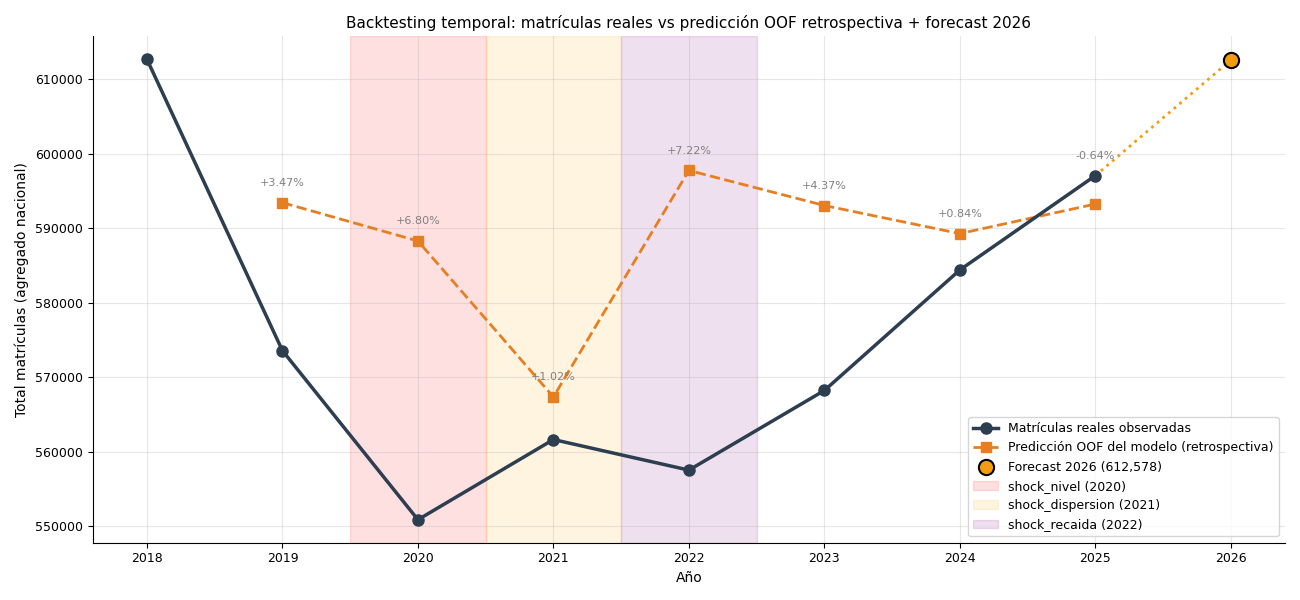


Errores agregados anuales del modelo (nivel nacional):
 año   real  predicho  error_abs  error_rel_%
2019 573548  593433.0    19885.0        3.467
2020 550847  588279.0    37432.0        6.795
2021 561614  567338.0     5724.0        1.019
2022 557507  597755.0    40248.0        7.219
2023 568204  593047.0    24843.0        4.372
2024 584391  589273.0     4882.0        0.835
2025 597058  593244.0    -3814.0       -0.639
  Tabla guardada: tabla_backtesting_anual.md


'|   año |   real |    predicho |   error_abs |   error_rel_% |\n|------:|-------:|------------:|------------:|--------------:|\n|  2019 | 573548 | 593433.0000 |  19885.0000 |        3.4670 |\n|  2020 | 550847 | 588279.0000 |  37432.0000 |        6.7950 |\n|  2021 | 561614 | 567338.0000 |   5724.0000 |        1.0190 |\n|  2022 | 557507 | 597755.0000 |  40248.0000 |        7.2190 |\n|  2023 | 568204 | 593047.0000 |  24843.0000 |        4.3720 |\n|  2024 | 584391 | 589273.0000 |   4882.0000 |        0.8350 |\n|  2025 | 597058 | 593244.0000 |  -3814.0000 |       -0.6390 |'

In [12]:
## =============================================================================
## FASE D.2 - BACKTESTING TEMPORAL AGREGADO (la "money figure" del paper)
## =============================================================================
## Histórico observado (incluyendo 2018) + predicción OOF retrospectiva +
## forecast 2026, todo agregado a nivel nacional.

## Histórico real (a partir de matriculas_real del OOF y 2018)
hist_real = pd.concat([
    df_2018.groupby("anio", observed=True)["matriculas_lag"].sum(),  ## fallback para 2018 (usa lag para reconstruir el total real)
    df_oof.groupby("anio", observed=True)["matriculas_real"].sum(),
]).sort_index()

## Predicciones del modelo
pred_oof_anual = df_oof.groupby("anio", observed=True)["matriculas_pred"].sum()
pred_forecast = df_forecast.groupby("anio", observed=True)["matriculas_pred"].sum()

print("Histórico real:")
print(hist_real.round(0).to_string())
print("\nPredicciones OOF (retrospectivas):")
print(pred_oof_anual.round(0).to_string())
print("\nForecast 2026:")
print(pred_forecast.round(0).to_string())

## --- Figura ---
fig, ax = plt.subplots(figsize=(13, 6))

## Línea de matrículas reales
ax.plot(hist_real.index, hist_real.values, marker="o", markersize=8, linewidth=2.5,
        color=PALETA_COLORES["real"], label="Matrículas reales observadas", zorder=3)

## Línea de predicciones OOF
ax.plot(pred_oof_anual.index, pred_oof_anual.values, marker="s", markersize=7,
        linewidth=2, linestyle="--", color=PALETA_COLORES["pred"],
        label="Predicción OOF del modelo (retrospectiva)", zorder=2)

## Forecast 2026 (con líneas conectoras)
ax.plot([2025, 2026], [hist_real.loc[2025], pred_forecast.iloc[0]],
        linewidth=2, linestyle=":", color=PALETA_COLORES["warning"], zorder=2)
ax.scatter([2026], [pred_forecast.iloc[0]], s=120, color=PALETA_COLORES["warning"],
           edgecolor="black", linewidth=1.5, label=f"Forecast 2026 ({pred_forecast.iloc[0]:,.0f})", zorder=4)

## Anotaciones de shock pandemia
ax.axvspan(2019.5, 2020.5, alpha=0.12, color="red", label="shock_nivel (2020)")
ax.axvspan(2020.5, 2021.5, alpha=0.12, color="orange", label="shock_dispersion (2021)")
ax.axvspan(2021.5, 2022.5, alpha=0.12, color="purple", label="shock_recaida (2022)")

ax.set_xlabel("Año")
ax.set_ylabel("Total matrículas (agregado nacional)")
ax.set_title("Backtesting temporal: matrículas reales vs predicción OOF retrospectiva + forecast 2026")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)
ax.ticklabel_format(style="plain", axis="y")

## Anotar errores % en cada año retrospectivo
for anio in pred_oof_anual.index:
    real_v = hist_real.loc[anio]
    pred_v = pred_oof_anual.loc[anio]
    err_pct = (pred_v - real_v) / real_v * 100
    ax.annotate(f"{err_pct:+.2f}%", xy=(anio, max(real_v, pred_v)),
                xytext=(0, 12), textcoords="offset points", ha="center",
                fontsize=8, color="gray")

plt.tight_layout()
guardar_figura(fig, "fig08_backtesting_temporal_MONEY_FIGURE.png")
plt.show()

## --- Tabla de errores agregados anuales ---
tabla_backtest = pd.DataFrame({
    "año": pred_oof_anual.index.astype(int),
    "real": hist_real.reindex(pred_oof_anual.index).values.round(0),
    "predicho": pred_oof_anual.values.round(0),
    "error_abs": (pred_oof_anual.values - hist_real.reindex(pred_oof_anual.index).values).round(0),
    "error_rel_%": ((pred_oof_anual.values - hist_real.reindex(pred_oof_anual.index).values)
                    / hist_real.reindex(pred_oof_anual.index).values * 100).round(3),
})
print("\nErrores agregados anuales del modelo (nivel nacional):")
print(tabla_backtest.to_string(index=False))
df_a_markdown(tabla_backtest, "tabla_backtesting_anual.md")

COMPARACIÓN DEL FORECAST 2026 CONTRA BASELINES SIMPLES
  Matrícula real 2025:                   597,058
  Forecast 2026 (modelo):                612,578  (+2.60%)
  Baseline lineal (regresión 2018-2025):    575,348  (-3.64%)
  Baseline promedio años normales:          610,860  (+2.31%)
  Baseline último año (variación 2025):     610,000  (+2.17%)

Diferencias del forecast vs baselines:
  vs Baseline lineal: +6.24 puntos porcentuales
  vs Baseline promedio años normales: +0.29 puntos porcentuales
  vs Baseline último año: +0.43 puntos porcentuales

=> El forecast 2026 SE APARTA notablemente de algunos baselines (revisar supuestos)
  Figura guardada: fig09_validacion_forecast_2026.png


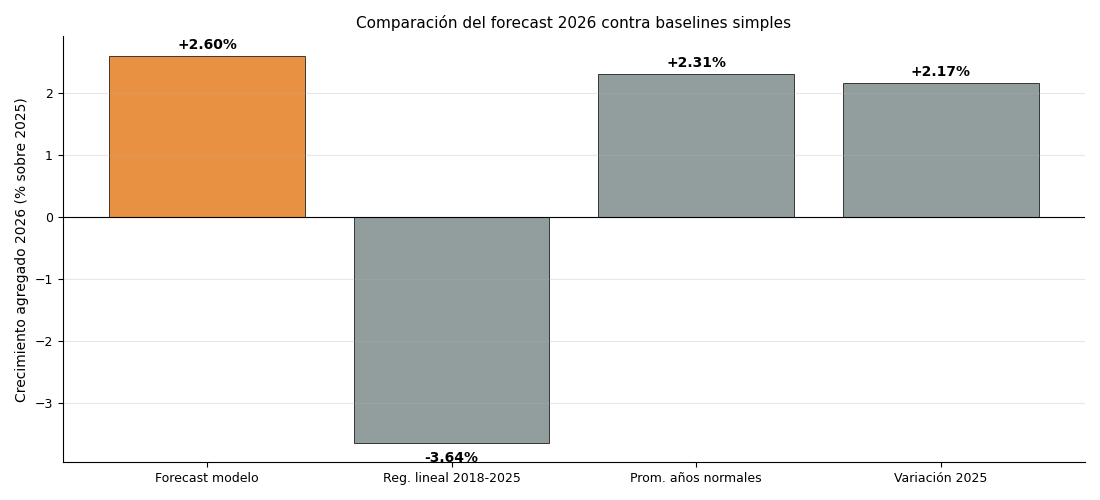

In [13]:
## =============================================================================
## FASE D.3 - VALIDACIÓN DE RAZONABILIDAD DEL FORECAST 2026
## =============================================================================
## Comparamos el +X.X% predicho contra 3 baselines simples para evaluar si
## el forecast es razonable o está fuera de rango.

real_2025 = hist_real.loc[2025]
pred_2026 = pred_forecast.iloc[0]
crec_predicho = (pred_2026 - real_2025) / real_2025 * 100

## Baseline 1: tendencia histórica (regresión lineal sobre 2018-2025)
years_hist = hist_real.index.values.astype(float)
slope, intercept, r_val, _, _ = stats.linregress(years_hist, hist_real.values)
pred_lineal_2026 = slope * 2026 + intercept
crec_lineal = (pred_lineal_2026 - real_2025) / real_2025 * 100

## Baseline 2: promedio de variaciones YoY de años normales
var_yoy = hist_real.pct_change() * 100
anos_normales = [2023, 2024, 2025]
crec_promedio_normales = var_yoy.loc[anos_normales].mean()

## Baseline 3: variación 2025 (último año observado)
crec_ultimo = var_yoy.loc[2025]

print("=" * 80)
print("COMPARACIÓN DEL FORECAST 2026 CONTRA BASELINES SIMPLES")
print("=" * 80)
print(f"  Matrícula real 2025:                {real_2025:>10,.0f}")
print(f"  Forecast 2026 (modelo):             {pred_2026:>10,.0f}  ({crec_predicho:+.2f}%)")
print(f"  Baseline lineal (regresión 2018-2025): {pred_lineal_2026:>10,.0f}  ({crec_lineal:+.2f}%)")
print(f"  Baseline promedio años normales:       {real_2025 * (1 + crec_promedio_normales/100):>10,.0f}  ({crec_promedio_normales:+.2f}%)")
print(f"  Baseline último año (variación 2025):  {real_2025 * (1 + crec_ultimo/100):>10,.0f}  ({crec_ultimo:+.2f}%)")

diferencias = {
    "vs Baseline lineal": crec_predicho - crec_lineal,
    "vs Baseline promedio años normales": crec_predicho - crec_promedio_normales,
    "vs Baseline último año": crec_predicho - crec_ultimo,
}
print("\nDiferencias del forecast vs baselines:")
for k, v in diferencias.items():
    print(f"  {k}: {v:+.2f} puntos porcentuales")

if max(abs(d) for d in diferencias.values()) < 2.0:
    print("\n=> El forecast 2026 es CONSISTENTE con los baselines simples (diferencias < 2 pp)")
else:
    print("\n=> El forecast 2026 SE APARTA notablemente de algunos baselines (revisar supuestos)")

## --- Figura: comparación visual ---
fig, ax = plt.subplots(figsize=(11, 5))

bench_labels = ["Forecast modelo", "Reg. lineal 2018-2025", "Prom. años normales", "Variación 2025"]
bench_values = [crec_predicho, crec_lineal, crec_promedio_normales, crec_ultimo]
colors = [PALETA_COLORES["pred"], PALETA_COLORES["neutral"], PALETA_COLORES["neutral"], PALETA_COLORES["neutral"]]

bars = ax.bar(bench_labels, bench_values, color=colors, alpha=0.85, edgecolor="black", linewidth=0.6)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Crecimiento agregado 2026 (% sobre 2025)")
ax.set_title("Comparación del forecast 2026 contra baselines simples")
for bar, val in zip(bars, bench_values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.1 if val >= 0 else val - 0.3,
            f"{val:+.2f}%", ha="center", fontsize=10, fontweight="bold")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
guardar_figura(fig, "fig09_validacion_forecast_2026.png")
plt.show()

In [14]:
## =============================================================================
## FASE D.4 - ANÁLISIS DE ERRORES EXTREMOS (limitaciones del modelo)
## =============================================================================
## ¿Qué combinaciones predice mejor el modelo? ¿Cuáles peor? Esto va a la
## sección de Limitaciones del paper.

df_err = df_oof.copy()
df_err["error_abs_n"] = df_err["residuo_matriculas"].abs()
df_err["error_rel_%"] = (df_err["error_abs_n"] / df_err["matriculas_real"].clip(lower=1)) * 100

## --- Top 15 errores más grandes (en n° matrículas absolutas) ---
top_peor_abs = df_err.nlargest(15, "error_abs_n")[
    ["anio", "institucion", "carrera", "region", "jornada", "condicion",
     "matriculas_real", "matriculas_pred", "error_abs_n", "error_rel_%"]
]
print("=" * 100)
print("TOP 15 PEORES PREDICCIONES (error absoluto en n° matrículas)")
print("=" * 100)
print(top_peor_abs.to_string(index=False))

## --- Top 15 mejores predicciones (entre filas con n>=50, para evitar trivialidades) ---
sub_grande = df_err[df_err["matriculas_real"] >= 50]
top_mejor = sub_grande.nsmallest(15, "error_rel_%")[
    ["anio", "institucion", "carrera", "region", "jornada", "condicion",
     "matriculas_real", "matriculas_pred", "error_abs_n", "error_rel_%"]
]
print(f"\n{'='*100}")
print("TOP 15 MEJORES PREDICCIONES (entre filas con matrícula real >= 50)")
print("=" * 100)
print(top_mejor.to_string(index=False))

## --- Análisis: ¿hay patrones? ¿en qué regiones/instituciones/jornadas se concentran los peores? ---
print(f"\n{'='*100}")
print("DISTRIBUCIÓN DE LOS 100 PEORES ERRORES (en valor absoluto)")
print("=" * 100)
top100_peor = df_err.nlargest(100, "error_abs_n")

for col in ["jornada", "condicion", "region"]:
    print(f"\n  Por {col}:")
    print((top100_peor[col].value_counts(normalize=True) * 100).round(1).to_string())

df_a_markdown(top_peor_abs, "tabla_top15_peores_predicciones.md")
df_a_markdown(top_mejor, "tabla_top15_mejores_predicciones.md")

TOP 15 PEORES PREDICCIONES (error absoluto en n° matrículas)
 anio                                            institucion                                                 carrera        region        jornada condicion  matriculas_real  matriculas_pred  error_abs_n  error_rel_%
 2020                               UNIVERSIDAD ANDRES BELLO                                    INGENIERIA COMERCIAL Metropolitana         Diurna   ANTIGUO               64      2312.074707  2248.074707   3512.61673
 2020                               UNIVERSIDAD ANDRES BELLO                                    INGENIERIA COMERCIAL Metropolitana         Diurna   ANTIGUO               64      2311.929688  2247.929688  3512.390137
 2020                               UNIVERSIDAD ANDRES BELLO                                    INGENIERIA COMERCIAL Metropolitana         Diurna     NUEVO               64      1441.810059  1377.810059  2152.828217
 2020                               UNIVERSIDAD ANDRES BELLO               

'|   anio | institucion                             | carrera                                                                                                                                      | region        | jornada   | condicion   |   matriculas_real |   matriculas_pred |   error_abs_n |   error_rel_% |\n|-------:|:----------------------------------------|:---------------------------------------------------------------------------------------------------------------------------------------------|:--------------|:----------|:------------|------------------:|------------------:|--------------:|--------------:|\n|   2023 | UNIVERSIDAD SANTO TOMAS                 | ENFERMERIA                                                                                                                                   | Tarapacá      | Diurna    | ANTIGUO     |               157 |          157.0007 |        0.0007 |        0.0004 |\n|   2023 | UNIVERSIDAD SANTO TOMAS                 | MEDICINA VETE

Columnas SHAP detectadas: ['shap_top1_matriculas_lag1', 'shap_top2_CONDICION_NUEVO', 'shap_top3_NOMBRE CARRERA', 'shap_top4_pct_matricula_regional_lag', 'shap_top5_GENERO']
  Figura guardada: fig10_shap_top5_distribucion.png


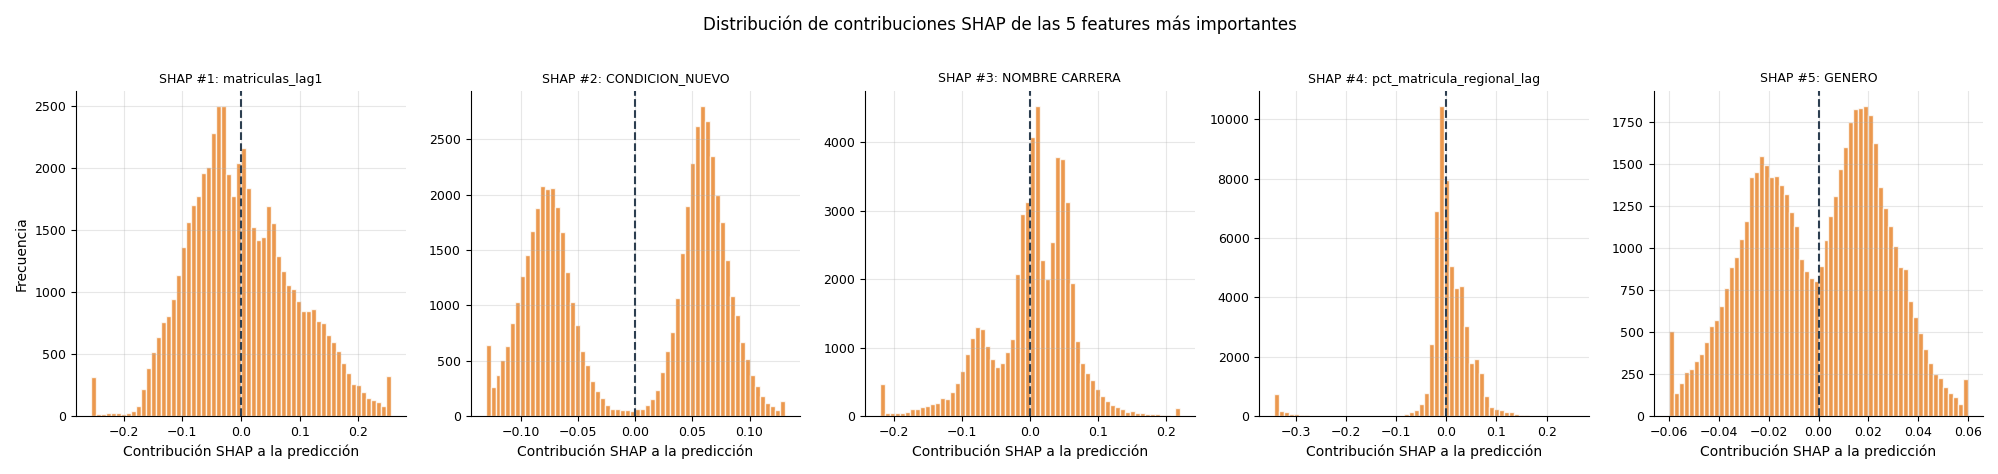


Resumen de las top 5 features por SHAP:
feature_rank               feature_name  mean_shap_abs  std_shap  pct_filas_positivas_%  pct_filas_negativas_%
          #1            matriculas_lag1         0.0731    0.0925                46.1633                53.8367
          #2            CONDICION_NUEVO         0.0702    0.0740                53.1916                46.8084
          #3             NOMBRE CARRERA         0.0469    0.0637                60.1250                39.8750
          #4 pct_matricula_regional_lag         0.0323    0.0637                51.5104                48.4896
          #5                     GENERO         0.0225    0.0263                51.8594                48.1406
  Tabla guardada: tabla_shap_top5_resumen.md


In [15]:
## =============================================================================
## FASE E.1 - DISTRIBUCIÓN DE SHAP TOP-5 (explicabilidad global)
## =============================================================================

shap_cols = sorted([c for c in df_full.columns if c.startswith("shap_top")])
print(f"Columnas SHAP detectadas: {shap_cols}")

if len(shap_cols) >= 5:
    df_shap = df_oof[shap_cols].copy()

    fig, axes = plt.subplots(1, len(shap_cols), figsize=(4 * len(shap_cols), 4.5))
    if len(shap_cols) == 1:
        axes = [axes]

    for i, col in enumerate(shap_cols):
        ax = axes[i]
        vals = df_shap[col].dropna().values
        ## Histograma centrado en cero
        vmax = np.percentile(np.abs(vals), 99)
        ax.hist(np.clip(vals, -vmax, vmax), bins=60, color=PALETA_COLORES["pred"],
                edgecolor="white", alpha=0.8)
        ax.axvline(0, color=PALETA_COLORES["real"], linestyle="--", linewidth=1.5)
        feature_name = col.replace("shap_top", "").split("_", 1)[1] if "_" in col else col
        ax.set_title(f"SHAP #{i+1}: {feature_name[:30]}", fontsize=9)
        ax.set_xlabel("Contribución SHAP a la predicción")
        ax.set_ylabel("Frecuencia" if i == 0 else "")
        ax.grid(True, alpha=0.3)

    plt.suptitle("Distribución de contribuciones SHAP de las 5 features más importantes", y=1.02)
    plt.tight_layout()
    guardar_figura(fig, "fig10_shap_top5_distribucion.png")
    plt.show()

    ## --- Tabla resumen de magnitud SHAP ---
    tabla_shap_summary = pd.DataFrame({
        "feature_rank": [f"#{i+1}" for i in range(len(shap_cols))],
        "feature_name": [c.replace("shap_top", "").split("_", 1)[1] if "_" in c else c for c in shap_cols],
        "mean_shap_abs": [df_shap[c].abs().mean() for c in shap_cols],
        "std_shap": [df_shap[c].std() for c in shap_cols],
        "pct_filas_positivas_%": [(df_shap[c] > 0).mean() * 100 for c in shap_cols],
        "pct_filas_negativas_%": [(df_shap[c] < 0).mean() * 100 for c in shap_cols],
    })
    print("\nResumen de las top 5 features por SHAP:")
    print(tabla_shap_summary.round(4).to_string(index=False))
    df_a_markdown(tabla_shap_summary, "tabla_shap_top5_resumen.md")
else:
    print("No hay suficientes columnas SHAP en el parquet para este análisis.")

  Figura guardada: fig11_shap_por_subgrupo.png


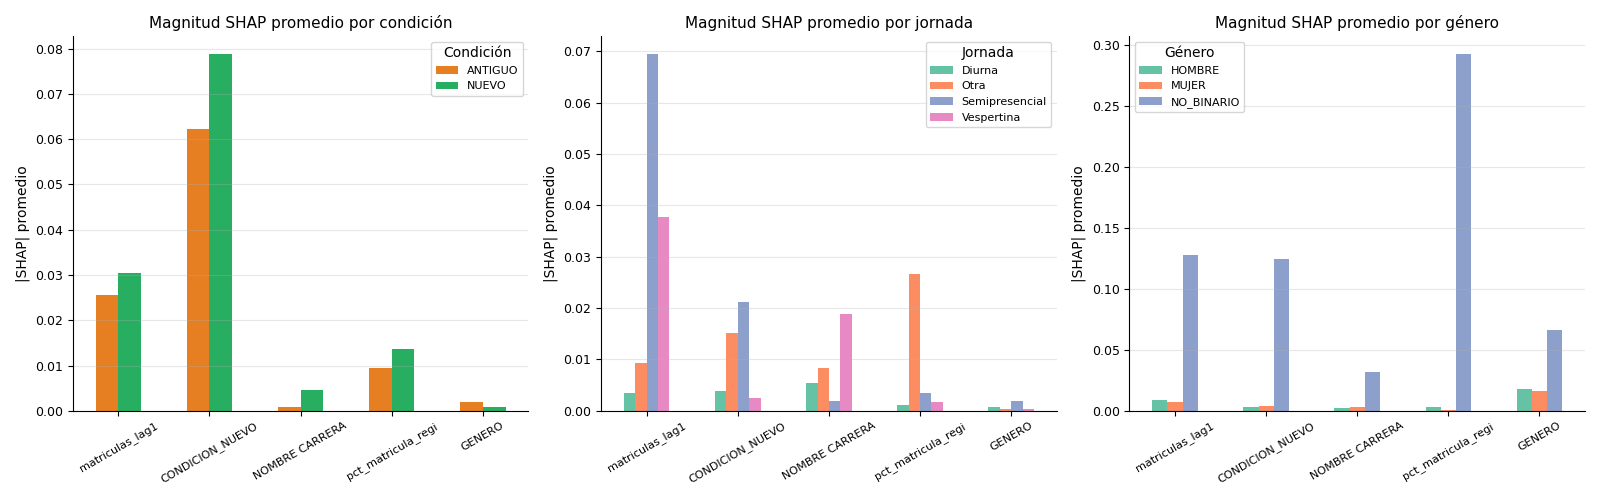

In [16]:
## =============================================================================
## FASE E.2 - SHAP POR SUBGRUPO (¿qué pesa más en cada tipo de fila?)
## =============================================================================

if len(shap_cols) >= 5:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    ## Panel 1: SHAP medio por CONDICION (NUEVO vs ANTIGUO)
    ax = axes[0]
    grp = df_oof.groupby("condicion", observed=True)[shap_cols].mean().abs()
    grp.columns = [c.replace("shap_top", "").split("_", 1)[1][:18] if "_" in c else c for c in grp.columns]
    grp.T.plot(kind="bar", ax=ax, color=[PALETA_COLORES["pred"], PALETA_COLORES["ok"]])
    ax.set_title("Magnitud SHAP promedio por condición")
    ax.set_xlabel(""); ax.set_ylabel("|SHAP| promedio")
    ax.legend(title="Condición", fontsize=8)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.grid(True, axis="y", alpha=0.3)

    ## Panel 2: SHAP medio por JORNADA
    ax = axes[1]
    grp = df_oof.groupby("jornada", observed=True)[shap_cols].mean().abs()
    grp.columns = [c.replace("shap_top", "").split("_", 1)[1][:18] if "_" in c else c for c in grp.columns]
    grp.T.plot(kind="bar", ax=ax)
    ax.set_title("Magnitud SHAP promedio por jornada")
    ax.set_xlabel(""); ax.set_ylabel("|SHAP| promedio")
    ax.legend(title="Jornada", fontsize=8)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.grid(True, axis="y", alpha=0.3)

    ## Panel 3: SHAP medio por GÉNERO
    ax = axes[2]
    grp = df_oof.groupby("genero", observed=True)[shap_cols].mean().abs()
    grp.columns = [c.replace("shap_top", "").split("_", 1)[1][:18] if "_" in c else c for c in grp.columns]
    grp.T.plot(kind="bar", ax=ax)
    ax.set_title("Magnitud SHAP promedio por género")
    ax.set_xlabel(""); ax.set_ylabel("|SHAP| promedio")
    ax.legend(title="Género", fontsize=8)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    guardar_figura(fig, "fig11_shap_por_subgrupo.png")
    plt.show()

  Figura guardada: fig12_caso_estudio_shap.png


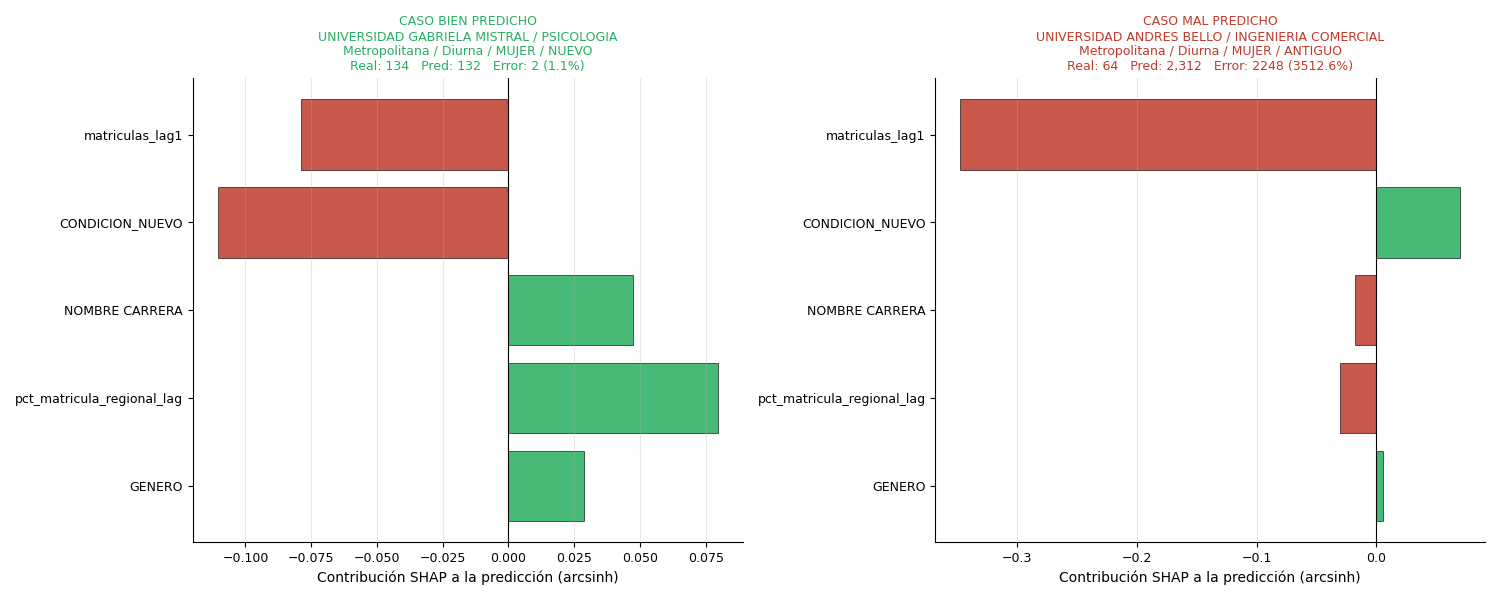

In [17]:
## =============================================================================
## FASE E.3 - CASO DE ESTUDIO: descomposición SHAP de 1 buena y 1 mala
## =============================================================================
## Tomamos un caso bien predicho y uno mal predicho, y mostramos sus SHAP
## descompuestos. Útil para la sección de Discusión del paper.

if len(shap_cols) >= 5:
    ## Caso 1: predicción muy buena (filas con matrícula real >= 100 y error_abs <= 2)
    candidatos_buenos = df_err[(df_err["matriculas_real"] >= 100) & (df_err["error_abs_n"] <= 2)]
    if len(candidatos_buenos) > 0:
        caso_bueno = candidatos_buenos.iloc[0]
    else:
        caso_bueno = df_err.nsmallest(1, "error_rel_%").iloc[0]

    ## Caso 2: predicción muy mala
    caso_malo = df_err.nlargest(1, "error_abs_n").iloc[0]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    for ax, caso, titulo, color in [
        (axes[0], caso_bueno, "CASO BIEN PREDICHO", PALETA_COLORES["ok"]),
        (axes[1], caso_malo, "CASO MAL PREDICHO", PALETA_COLORES["error"]),
    ]:
        shap_vals = [caso[c] for c in shap_cols]
        feature_names = [c.replace("shap_top", "").split("_", 1)[1] if "_" in c else c for c in shap_cols]

        colors_bars = [PALETA_COLORES["ok"] if v > 0 else PALETA_COLORES["error"] for v in shap_vals]
        y = np.arange(len(shap_cols))
        ax.barh(y, shap_vals, color=colors_bars, alpha=0.85, edgecolor="black", linewidth=0.5)
        ax.set_yticks(y); ax.set_yticklabels(feature_names)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_xlabel("Contribución SHAP a la predicción (arcsinh)")
        ax.set_title(f"{titulo}\n{caso['institucion'][:35]} / {caso['carrera'][:35]}\n"
                     f"{caso['region']} / {caso['jornada']} / {caso['genero']} / {caso['condicion']}\n"
                     f"Real: {caso['matriculas_real']:,.0f}   Pred: {caso['matriculas_pred']:,.0f}   "
                     f"Error: {caso['error_abs_n']:.0f} ({caso['error_rel_%']:.1f}%)",
                     fontsize=9, color=color)
        ax.invert_yaxis()
        ax.grid(True, axis="x", alpha=0.3)

    plt.tight_layout()
    guardar_figura(fig, "fig12_caso_estudio_shap.png")
    plt.show()

In [18]:
## =============================================================================
## FASE F.1 - TABLA RESUMEN PARA EL PAPER (Tabla principal de resultados)
## =============================================================================

resumen_final = pd.DataFrame([
    {
        "Dataset": "OOF retrospectivo (2019-2025)",
        "n filas": m_oof["n"],
        "RMSE": m_oof["RMSE"],
        "MAE": m_oof["MAE"],
        "R²": m_oof["R²"],
        "WAPE (%)": m_oof["WAPE_%"],
        "Confianza (%)": m_oof["confianza_%"],
        "Skill vs naïve (%)": skill_oof * 100,
    },
    {
        "Dataset": "Holdout 2025",
        "n filas": m_holdout["n"],
        "RMSE": m_holdout["RMSE"],
        "MAE": m_holdout["MAE"],
        "R²": m_holdout["R²"],
        "WAPE (%)": m_holdout["WAPE_%"],
        "Confianza (%)": m_holdout["confianza_%"],
        "Skill vs naïve (%)": skill_holdout * 100,
    },
])

print("=" * 100)
print("TABLA RESUMEN FINAL (para el paper)")
print("=" * 100)
print(resumen_final.to_string(index=False))

df_a_markdown(resumen_final, "tabla_resumen_paper.md")

TABLA RESUMEN FINAL (para el paper)
                      Dataset  n filas      RMSE       MAE       R²  WAPE (%)  Confianza (%)  Skill vs naïve (%)
OOF retrospectivo (2019-2025)    54721 36.637800 13.395717 0.876737 18.357024      81.642976           62.133897
                 Holdout 2025     7752 26.593088 11.562845 0.943952 15.012809      84.987191           49.446999
  Tabla guardada: tabla_resumen_paper.md


'| Dataset                       |   n filas |    RMSE |     MAE |     R² |   WAPE (%) |   Confianza (%) |   Skill vs naïve (%) |\n|:------------------------------|----------:|--------:|--------:|-------:|-----------:|----------------:|---------------------:|\n| OOF retrospectivo (2019-2025) |     54721 | 36.6378 | 13.3957 | 0.8767 |    18.3570 |         81.6430 |              62.1339 |\n| Holdout 2025                  |      7752 | 26.5931 | 11.5628 | 0.9440 |    15.0128 |         84.9872 |              49.4470 |'

In [19]:
## =============================================================================
## FASE F.2 - EXPORT FINAL DE TODAS LAS MÉTRICAS A JSON
## =============================================================================

metricas_completas = {
    "fuente_datos": str(PARQUET_PATH.name),
    "fecha_analisis": datetime.now().isoformat(),
    "global": {
        "OOF_retrospectivo": m_oof,
        "Holdout_2025": m_holdout,
        "skill_score_vs_naive_OOF": skill_oof,
        "skill_score_vs_naive_Holdout": skill_holdout,
    },
    "por_año_OOF": tabla_anios.to_dict(orient="records"),
    "por_region_OOF": tabla_regiones.to_dict(orient="records"),
    "macro_a_micro_OOF": tabla_oof.to_dict(orient="records"),
    "macro_a_micro_HOLDOUT": tabla_holdout.to_dict(orient="records"),
    "backtesting_anual": tabla_backtest.to_dict(orient="records"),
    "forecast_2026": {
        "prediccion_total": float(pred_2026),
        "real_2025": float(real_2025),
        "crecimiento_pct": float(crec_predicho),
        "vs_baseline_lineal_pp": float(crec_predicho - crec_lineal),
        "vs_baseline_anos_normales_pp": float(crec_predicho - crec_promedio_normales),
    },
}

path_json = OUTPUTS_PAPER / "metricas_completas_paper.json"
with open(path_json, "w", encoding="utf-8") as f:
    json.dump(metricas_completas, f, indent=2, ensure_ascii=False, default=str)

print(f"Métricas completas exportadas a: {path_json}")
print(f"\nArchivos generados en {OUTPUTS_PAPER}:")
for f in sorted(FIGURAS_DIR.glob("*.png")):
    print(f"  Figuras/ {f.name}  ({f.stat().st_size/1024:.0f} KB)")
for f in sorted(TABLAS_DIR.glob("*.md")):
    print(f"  Tablas/  {f.name}")

Métricas completas exportadas a: C:\Users\diego.perezp\Documents\GitHub\Predictive model of university admission\OUTPUTS_PAPER\metricas_completas_paper.json

Archivos generados en C:\Users\diego.perezp\Documents\GitHub\Predictive model of university admission\OUTPUTS_PAPER:
  Figuras/ fig01_distribucion_residuos.png  (190 KB)
  Figuras/ fig02_scatter_pred_vs_real.png  (370 KB)
  Figuras/ fig03_metricas_por_anio.png  (247 KB)
  Figuras/ fig04_wape_por_region.png  (207 KB)
  Figuras/ fig05_macro_a_micro.png  (1054 KB)
  Figuras/ fig06_evolucion_metricas_por_nivel.png  (247 KB)
  Figuras/ fig07_calibracion.png  (230 KB)
  Figuras/ fig08_backtesting_temporal_MONEY_FIGURE.png  (364 KB)
  Figuras/ fig09_validacion_forecast_2026.png  (125 KB)
  Figuras/ fig10_shap_top5_distribucion.png  (250 KB)
  Figuras/ fig11_shap_por_subgrupo.png  (242 KB)
  Figuras/ fig12_caso_estudio_shap.png  (212 KB)
  Tablas/  tabla_backtesting_anual.md
  Tablas/  tabla_macro_a_micro_HOLDOUT.md
  Tablas/  tabla_macro

In [20]:
## =============================================================================
## FASE F.3 - RESUMEN EJECUTIVO PARA EL PAPER
## =============================================================================

print(f'''
{"=" * 80}
RESUMEN EJECUTIVO - ANÁLISIS DE RESULTADOS PARA EL PAPER
{"=" * 80}

MODELO: CatBoost_tuned (corrida sobre {PARQUET_PATH.name})

GRANULARIDAD DEL DATASET:
  Filas evaluadas en OOF retrospectivo: {m_oof["n"]:,}
  Filas evaluadas en Holdout 2025:      {m_holdout["n"]:,}

DESEMPEÑO A NIVEL FILA INDIVIDUAL (granularidad máxima - inst x carrera x ... x jornada):
  OOF retrospectivo:
    RMSE = {m_oof["RMSE"]:.2f}    R² = {m_oof["R²"]:.4f}    WAPE = {m_oof["WAPE_%"]:.2f}%    Confianza = {m_oof["confianza_%"]:.2f}%
  Holdout 2025:
    RMSE = {m_holdout["RMSE"]:.2f}    R² = {m_holdout["R²"]:.4f}    WAPE = {m_holdout["WAPE_%"]:.2f}%    Confianza = {m_holdout["confianza_%"]:.2f}%

  Skill Score vs baseline naïve (matrícula_t = matrícula_t-1):
    OOF:      {skill_oof*100:+.2f}%
    Holdout:  {skill_holdout*100:+.2f}%

PRECISIÓN POR NIVEL DE AGREGACIÓN (OOF retrospectivo):
  Nivel 1 (Nacional anual):                  WAPE = {resultados_oof[0]["WAPE_%"]:.2f}%  Confianza = {resultados_oof[0]["confianza_%"]:.2f}%
  Nivel 4 (+ Región):                        WAPE = {resultados_oof[3]["WAPE_%"]:.2f}%  Confianza = {resultados_oof[3]["confianza_%"]:.2f}%
  Nivel 8 (granularidad fina):               WAPE = {resultados_oof[7]["WAPE_%"]:.2f}%  Confianza = {resultados_oof[7]["confianza_%"]:.2f}%

FORECAST 2026:
  Predicción agregada nacional:       {pred_2026:>10,.0f} matrículas
  Crecimiento vs 2025:                {crec_predicho:+.2f}%
  Diferencia vs baseline lineal:      {crec_predicho - crec_lineal:+.2f} pp
  Diferencia vs promedio años normal: {crec_predicho - crec_promedio_normales:+.2f} pp

ARCHIVOS GENERADOS:
  Figuras: {len(list(FIGURAS_DIR.glob("*.png")))} PNGs en 300 dpi
  Tablas:  {len(list(TABLAS_DIR.glob("*.md")))} archivos .md
  JSON:    metricas_completas_paper.json (trazabilidad completa)

PRÓXIMOS PASOS:
  1. Revisar las figuras en {FIGURAS_DIR}
  2. Las tablas .md se pueden pegar directamente en el draft del paper
  3. Generar el draft del paper usando estas métricas y figuras
''')


RESUMEN EJECUTIVO - ANÁLISIS DE RESULTADOS PARA EL PAPER

MODELO: CatBoost_tuned (corrida sobre predicciones_modelo_final_20260615_1210.parquet)

GRANULARIDAD DEL DATASET:
  Filas evaluadas en OOF retrospectivo: 54,721
  Filas evaluadas en Holdout 2025:      7,752

DESEMPEÑO A NIVEL FILA INDIVIDUAL (granularidad máxima - inst x carrera x ... x jornada):
  OOF retrospectivo:
    RMSE = 36.64    R² = 0.8767    WAPE = 18.36%    Confianza = 81.64%
  Holdout 2025:
    RMSE = 26.59    R² = 0.9440    WAPE = 15.01%    Confianza = 84.99%

  Skill Score vs baseline naïve (matrícula_t = matrícula_t-1):
    OOF:      +62.13%
    Holdout:  +49.45%

PRECISIÓN POR NIVEL DE AGREGACIÓN (OOF retrospectivo):
  Nivel 1 (Nacional anual):                  WAPE = 3.43%  Confianza = 96.57%
  Nivel 4 (+ Región):                        WAPE = 9.52%  Confianza = 90.48%
  Nivel 8 (granularidad fina):               WAPE = 18.32%  Confianza = 81.68%

FORECAST 2026:
  Predicción agregada nacional:          612,578 